# Installation et importation des bibliothèques

In [26]:
import time
print("---INSTALLATION DES BIBLIOTHEQUES EN COURS...---")
start_time = time.time()
!pip install -q monai[nibabel,pillow,itk]
!pip uninstall -y cupy cupy-cuda11x cupy-cuda12x
finish_time = time.time()
print(f"INSTALLATION DES BIBLIOTHEQUES FINIE EN {finish_time - start_time:.2f} SECONDES")

print("---IMPORTATION DES BIBLIOTHEQUES EN COURS...---")
start_time = time.time()
import gc
import glob
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import os
import random
import scipy.ndimage as ndimage
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
from google.colab import drive

# Importations MONAI
from monai.data import CacheDataset, DataLoader
from monai.data import Dataset as MonaiDataset
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric, HausdorffDistanceMetric, SurfaceDistanceMetric
from monai.networks.nets import DynUNet
from monai.transforms import (
     AsDiscrete, CenterSpatialCropd, Compose, EnsureChannelFirstd, EnsureTyped, KeepLargestConnectedComponent, LoadImaged, RandCropByPosNegLabeld, ScaleIntensityd
)

# Importations Scikit-image pour la géométrie
from skimage.measure import label, regionprops, perimeter, marching_cubes
from skimage.morphology import binary_erosion

# Importation des outils de précision mixte (AMP)
from torch.amp import autocast, GradScaler

from tqdm.notebook import tqdm

# Vérification du matériel (GPU ou CPU)
print("INITIALISATION DU MATERIEL ET DES DOSSIERS")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Calculs exécutés sur {device}")

finish_time = time.time()
print(f"IMPORTATION DES BIBLIOTHEQUES FINIE EN {finish_time - start_time:.2f} SECONDES")

---INSTALLATION DES BIBLIOTHEQUES EN COURS...---
INSTALLATION DES BIBLIOTHEQUES FINIE EN 6.33 SECONDES
---IMPORTATION DES BIBLIOTHEQUES EN COURS...---
INITIALISATION DU MATERIEL ET DES DOSSIERS
Calculs exécutés sur cuda
IMPORTATION DES BIBLIOTHEQUES FINIE EN 0.00 SECONDES


# Connection Drive et scan patients

In [2]:
if not os.path.exists('/content/drive'):
  drive.mount('/content/drive')
base_projet = '/content/drive/MyDrive/TFE_Segmentation'
root_dir = os.path.join(base_projet, 'Datasets', 'Task02_Heart')
os.makedirs(os.path.join(base_projet, '3D'), exist_ok=True)

print("---SCAN DES PATIENTS EN COURS...---")
start_time = time.time()
images = sorted(glob.glob(os.path.join(root_dir, "imagesTr", "*.nii.gz")))
labels = sorted(glob.glob(os.path.join(root_dir, "labelsTr", "*.nii.gz")))

# Appariement sécurisé par le nom de fichier pour éviter tout décalage
data = []
for img_path in images:
  nom_base = os.path.basename(img_path)
  lbl_path = next((lbl for lbl in labels if nom_base in lbl), None)
  if lbl_path:
    data.append({"image": img_path, "label":lbl_path})

if len(data) == 0:
  raise FileNotFoundError(f"Aucun couple image/label trouvé dans {root_dir}")
print(f"Nombre de patients Décathlon : {len(data)}")

# Fixation d'une graine aléatoire pour que le mélange soit reproductible à chaque lancement
random.seed(42)
random.shuffle(data)

# Découpage 4/5 entrainement et 1/5 validation
split_idx = int(len(data) * 0.8)
train_data = data[:split_idx]
val_data = data[split_idx:]

finish_time = time.time()
print(f"Patients d'entrainement : {len(train_data)}")
print(f"Patients de validation : {len(val_data)}")
print(f"SCAN DES PATIENTS FINI EN {finish_time - start_time:.2f} SECONDES")

Mounted at /content/drive
---SCAN DES PATIENTS EN COURS...---
Nombre de patients Décathlon : 20
Patients d'entrainement : 16
Patients de validation : 4
SCAN DES PATIENTS FINI EN 0.87 SECONDES


# Transformations Monai et dataset 3D en cache

In [3]:
transforms_train = Compose([
    # Chargement des volumes NiFTI (.nii.gz)
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),

    # Normalisation du contraste médical (0 à 1)
    ScaleIntensityd(keys="image"),

    # Extraction d'un cube 64x64x64 en s'assurant qu'il contient le label du coeur (remplacement de l'extraction de tranches 2D)
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(96, 96, 96),
        pos=1,
        neg=1,
        num_samples=1,
        image_key="image",
        image_threshold=0,
    ),
    EnsureTyped(keys=["image", "label"]),
])

transforms_val = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ScaleIntensityd(keys="image"),
    CenterSpatialCropd(keys=["image", "label"], roi_size=(96, 96, 96)),
    EnsureTyped(keys=["image", "label"]),
])

# Chargement initial en RAM via CacheDataset
print(f"---CHARGEMENT DU DATASET 3D EN COURS...---")
start_time = time.time()
train_ds = MonaiDataset(data=train_data, transform=transforms_train)
val_ds = MonaiDataset(data=val_data, transform=transforms_val)
finish_time = time.time()
print(f"\nCHARGEMENT DU DATASET FINI EN {finish_time - start_time:.2f} SECONDES")

# Wrapper Pytorch (génération de la LR à la volée)
class Dataset_3D_SR_Seg(Dataset):
  def __init__(self, monai_cache_dataset, scale_factor=2):
    self.dataset = monai_cache_dataset
    self.scale_factor = scale_factor

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    # Récupération du cube 64x64x64 depuis le cache Monai
    item = self.dataset[idx]
    data = item[0] if isinstance(item, (list,tuple)) else item

    hr_tensor = data["image"]
    label_tensor = data["label"]

    # Sécurité dimensionnelle : Force une taille exacte de (64, 64, 64) pour éviter le bug des tailles difféerentes
    if hr_tensor.shape[1:] != (96, 96, 96):
      hr_tensor = F.interpolate(hr_tensor.unsqueeze(0), size=(96, 96, 96), mode='trilinear', align_corners=False).squeeze(0)
      label_tensor = F.interpolate(label_tensor.unsqueeze(0).float(), size=(96, 96, 96), mode='nearest').squeeze(0).long()

    # Dégradation 3D
    _, d, h, w = hr_tensor.shape
    lr_d = d // self.scale_factor
    lr_h = h // self.scale_factor
    lr_w = w // self.scale_factor

    # Rétrécissement du volume
    lr_tensor = F.interpolate(hr_tensor.unsqueeze(0), size=(lr_d, lr_h, lr_w), mode='trilinear', align_corners=False)
    # Réagrandissement pour créer le flou
    lr_tensor = F.interpolate(lr_tensor, size=(d, h, w), mode='trilinear', align_corners=False).squeeze(0)

    # Return les 3 tenseurs (entrée LR, cible SR, futur masque de segmentation)
    return hr_tensor, lr_tensor, label_tensor

# Préparation des DataLoaders
train_dataset_3d = Dataset_3D_SR_Seg(train_ds, scale_factor=2)
val_dataset_3d = Dataset_3D_SR_Seg(val_ds, scale_factor=2)

# Batch_size réduit à 4 car le poids des volumes 3D en VRAM est immportant
train_loader = DataLoader(train_dataset_3d, batch_size=1, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset_3d, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)
finish_time = time.time()
print(f"Dataset prêt. Entrainement : {len(train_dataset_3d)} patients / Validation : {len(val_dataset_3d)} patients")
print(f"CHARGEMENT DU DATASET FINI EN {finish_time - start_time:.2f} SECONDES")

---CHARGEMENT DU DATASET 3D EN COURS...---

CHARGEMENT DU DATASET FINI EN 0.00 SECONDES
Dataset prêt. Entrainement : 16 patients / Validation : 4 patients
CHARGEMENT DU DATASET FINI EN 0.02 SECONDES


# Fonctions de perte, métriques, architectures réseaux

In [4]:
# Définition des métriques
# loss_function = DiceLoss(sigmoid=True)
loss_function = DiceCELoss(sigmoid=True, lambda_dice=0.5, lambda_ce=0.5)
loss_mse = nn.MSELoss() # Utilisé que pour la phase de pré-entrainement du SRCNN solo

# Métriques spatiales et surfaciques
hd95_metric = HausdorffDistanceMetric(include_background=False, percentile=95, reduction="mean")
dice_metric = DiceMetric(include_background=False, reduction="mean")

post_binarize = AsDiscrete(threshold=0.5) # Binarisation à 0.5 pour s'aligner sur la simgoid
keep_largest = KeepLargestConnectedComponent(applied_labels=[1]) # Cible la structure binaire

# Génération d'un modèle U-Net 3D
def creation_model():
  unet_model = DynUNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    # 5 niveaux de profondeur (comme le nn-Unet par défaut pour ces tailles)
    kernel_size=[(3, 3, 3),(3, 3, 3),(3, 3, 3),(3, 3, 3),(3, 3, 3)],
    strides=[(1, 1, 1), (2, 2, 2), (2, 2, 2), (2, 2, 2), (2, 2, 2)],
    upsample_kernel_size=[(2, 2, 2), (2, 2, 2), (2, 2, 2), (2, 2, 2), (2, 2, 2)],
    # Filtres plus larges pour capter les micro-détails de l'atrium
    filters=[32, 64, 128, 256, 512],
    dropout=0.2,
    res_block=True,
  ).to(device)
  return unet_model

# Création d'un modèle SRCNN avec une connexion résiduelle globale
class SRCNN(nn.Module):
  def __init__(self):
    super(SRCNN, self).__init__()
    # Architecture classique 9-1-5, ici Conv3D
    self.conv1 = nn.Conv3d(in_channels=1, out_channels=64, kernel_size=9, padding=9 // 2)
    self.conv2 = nn.Conv3d(in_channels=64, out_channels=32, kernel_size=1, padding=1 // 2)
    self.conv3 = nn.Conv3d(in_channels=32, out_channels=1, kernel_size=5, padding=5 // 2)
    self.relu = nn.ReLU(inplace=True)

  def forward(self, x):
    # Entrée x : tenseur LR flou [B, 1, 64, 64, 64]/ Sortie : tenseur super résolu [B, 1, 64, 64, 64]
    # Passage à travers les couches de convolution du SRCNN
    out = self.relu(self.conv1(x))
    out = self.relu(self.conv2(out))
    out = self.conv3(out)
    # Reconstruction sub-pixel vers l'échelle supérieure (256x256)
    return torch.clamp(x + out, 0.0, 1.0) # Addition du flou (x) et des détails (out)

print("Modèles 3D et métriques prêts)")

Modèles 3D et métriques prêts)


# Moteurs d'entrainement et de validation (multi-task loss et anti-air)

In [5]:
nb_epochs = 200
torch.backends.cudnn.benchmark = True

def entrainement_model(num_cas, unet_model, srcnn_model, optimizer, nom_fichiers):
  print(f"---ENTRAINEMENT DU CAS {num_cas} SUR {nb_epochs} EPOQUES EN COURS...---")

  historique_trainloss, historique_valloss, historique_dice, historique_hausdorff = [], [], [], []
  meilleur_dice = 0.0
  start_time = time.time()

  # Initialisation du scaler pour la précision mixte (AMP)
  device_type = "cuda" if torch.cuda.is_available() else "cpu"
  scaler = GradScaler(enabled=(device_type == "cuda"))

  # Extraction propre des noms de fichiers (gère si c'est un tuple ou une chaîne unique)
  nom_unet = nom_fichiers[0] if isinstance(nom_fichiers, (tuple, list)) else nom_fichiers
  nom_srcnn = nom_fichiers[1] if (isinstance(nom_fichiers, (tuple, list)) and len(nom_fichiers) > 1) else "srcnn_default"

  for epoch in range(nb_epochs):
      unet_model.train()

      # Gestion du comportement du SRCNN selon le cas
      if num_cas == 4 and srcnn_model is not None:
        srcnn_model.train()
      elif srcnn_model is not None:
        srcnn_model.eval()

      running_loss = 0.0

      for targets_hr, inputs_lr, inputs_labels in tqdm(train_loader, desc=f"Epoch : {epoch+1}/{nb_epochs}", leave=False):
          targets_hr = targets_hr.to(device) # Tenseur de taille (256x256)
          inputs_lr = inputs_lr.to(device) # Tenseur de taille (128x128)
          inputs_labels = inputs_labels.to(device) # Cible finale pour le UNET (256x256)

          optimizer.zero_grad()

          with autocast(device_type=device_type, enabled=(device_type == 'cuda')):
            if num_cas == 1: # Baseline HR Native
              outputs = unet_model(targets_hr)
              loss = loss_function(outputs, inputs_labels)

            elif num_cas == 2: # Baseline LR (interpolation trilinéaire 3D)
              inputs_upsampled = F.interpolate(inputs_lr, size=targets_hr.shape[2:], mode='trilinear', align_corners=False)
              outputs = unet_model(inputs_upsampled)
              loss = loss_function(outputs, inputs_labels)

            elif num_cas == 3: # Séquentiel (SRCNN pré-entrainé figé + U-Net)
              with torch.no_grad():
                inputs_sr = srcnn_model(inputs_lr)
              outputs = unet_model(inputs_sr.detach())
              loss = loss_function(outputs, inputs_labels)

            elif num_cas == 4: # Apprentissage conjoint (end-to-end) 100% Dice
              inputs_sr = srcnn_model(inputs_lr)
              outputs = unet_model(inputs_sr)

              # Ancrage multi-tache léger (95% Dice, 5% MSE)
              # Forcer le SRCNN à préserver les intensités de structure sans dériver en bruit
              loss_segmentation = loss_function(outputs, inputs_labels)
              loss_reconstruction = loss_mse(inputs_sr, targets_hr)
              loss = 0.95 * loss_segmentation + 0.05 * loss_reconstruction

          # Rétropropagation et mise à jour adaptées à la précision mixte AMP
          scaler.scale(loss).backward()
          scaler.step(optimizer)
          scaler.update()

          running_loss += loss.item()

      # Calcul de la perte d'entrainement moyenne pour l'époch
      train_loss = running_loss/len(train_loader)

      # Evaluation sur la partie validation
      val_loss, dice_score, hausdorff_score = validation_model(num_cas, unet_model, srcnn_model, epoch)

      # Gestion de la continuité des métriques surfaciques sur les époques non calculées
      if hausdorff_score < 0:
        hausdorff_score = historique_hausdorff[-1] if len(historique_hausdorff) > 0 else 0.0

      # Stockage des scores
      historique_trainloss.append(train_loss)
      historique_valloss.append(val_loss)
      historique_dice.append(dice_score)
      historique_hausdorff.append(hausdorff_score)

      if dice_score > meilleur_dice:
        meilleur_dice = dice_score
        torch.save(unet_model.state_dict(), os.path.join(base_projet, '3D', f'deca_{nom_unet}.pth'))
        if num_cas == 4 and srcnn_model is not None:
          torch.save(srcnn_model.state_dict(), os.path.join(base_projet, '3D', f'deca_{nom_srcnn}.pth'))

  print(f"ENTRAINEMENT TERMINE EN {time.time()-start_time:.2f} SECONDES\n")
  resultats = {'Train Loss' : historique_trainloss, 'Val Loss': historique_valloss, 'Dice': historique_dice, 'HD95': historique_hausdorff}
  return resultats


def validation_model(num_cas, unet_model, srcnn_model, epoch):
  unet_model.eval()
  if srcnn_model is not None:
    srcnn_model.eval()

  # Réinitialisation ultra-rapide des métriques existantes
  # Calcul des métriques surfaciques HD95 toutes les 10 époques
  dice_metric.reset()
  hd95_metric.reset()

  epoch_loss = 0.0
  device_type = "cuda" if torch.cuda.is_available() else "cpu"

  with torch.no_grad():
    for val_targets_hr, val_inputs_lr, val_labels in val_loader:
      # non_blocking+True permet de ne pas bloquer le CPU pendant le transfert vers le GPU
      val_targets_hr = val_targets_hr.to(device, non_blocking=True)
      val_inputs_lr = val_inputs_lr.to(device, non_blocking=True)
      val_labels = val_labels.to(device, non_blocking=True)

      if num_cas == 1:
        val_input = val_targets_hr
      elif num_cas == 2:
        val_input = F.interpolate(val_inputs_lr, size=val_targets_hr.shape[2:], mode='trilinear', align_corners=False)
      elif num_cas in (3, 4):
        val_input = srcnn_model(val_inputs_lr)

      # Evaluation sécurisée par l'autocast en validation
      with autocast(device_type=device_type, enabled=(device_type == 'cuda')):
        # Prédiction UNet
        val_outputs = unet_model(val_input)
        loss_dice = loss_function(val_outputs, val_labels)
      epoch_loss += loss_dice.item()

      # Post-traitement, binarisation vectorielle
      val_outputs_prob = torch.sigmoid(val_outputs)
      # Evaluation sur la binarisation brute à 50%
      val_bin_brut = (val_outputs_prob > 0.5).float()
      # Nettoyage avant évaluation
      val_bin = keep_largest(val_bin_brut)

      # Vérification que les labels et les prédictions sont de même taille
      assert val_labels.shape == val_bin.shape, f"Les dimensions des labels {val_labels.shape} et des prédictions {val_bin.shape} ne correspondent pas."

      # Calcul des métriques 3D par batch
      dice_metric(y_pred=val_bin, y=val_labels)
      hd95_metric(y_pred=val_bin, y=val_labels)


  # Calcul de la perte moyenne
  epoch_loss /= len(val_loader)

  # Agrégation Dice
  dice_res = dice_metric.aggregate()
  if isinstance(dice_res, (list,tuple)):
    dice_score = dice_res[0].item()
  else:
    dice_score = dice_res.item()

# Initialisation par défaut obligatoire pour éviter l'UnboundLocalError
  hd95_score = -1.0

  # Agrégation HD95 / ASSD
  hd95_res = hd95_metric.aggregate()
  if isinstance(hd95_res, (list,tuple)):
    hd95_val = hd95_res[0].item()
  else:
    hd95_val = hd95_res.item()

  if not np.isnan(hd95_val) and not np.isinf(hd95_val):
    hd95_score = float(hd95_val)
  else:
    hd95_score = 50.0

  return epoch_loss, dice_score, hd95_score

# Exécution des cas 1 à 4

In [6]:
"""# Fonction pour éviter la répétition du vidage de cache
def nettoyer_memoire_gpu(*objets):
  for obj in objets:
    if obj is not None:
      del obj
  torch.cuda.empty_cache()
  gc.collect()

dossier_model = os.path.join(base_projet, '3D')
os.makedirs(dossier_model, exist_ok=True)
device_type = "cuda" if torch.cuda.is_available() else "cpu"
"""

'# Fonction pour éviter la répétition du vidage de cache\ndef nettoyer_memoire_gpu(*objets):\n  for obj in objets:\n    if obj is not None:\n      del obj\n  torch.cuda.empty_cache()\n  gc.collect()\n\ndossier_model = os.path.join(base_projet, \'3D\')\nos.makedirs(dossier_model, exist_ok=True)\ndevice_type = "cuda" if torch.cuda.is_available() else "cpu"\n'

# Cas 1 : Baseline Haute Résolution Native

In [7]:
"""unet_model1 = creation_model()
optimizer1 = torch.optim.Adam(unet_model1.parameters(), lr=0.001, weight_decay=1e-5) # Mise à jour des paramètres uniquement du UNet
resultats1 = entrainement_model(1, unet_model1, None, optimizer1, ('model1', ''))
nettoyer_memoire_gpu(unet_model1, optimizer1)"""

"unet_model1 = creation_model()\noptimizer1 = torch.optim.Adam(unet_model1.parameters(), lr=0.001, weight_decay=1e-5) # Mise à jour des paramètres uniquement du UNet\nresultats1 = entrainement_model(1, unet_model1, None, optimizer1, ('model1', ''))\nnettoyer_memoire_gpu(unet_model1, optimizer1)"

# Cas 2 : Baseline Basse Résolution Interpolée (Trilinéaire)

In [8]:
"""unet_model2 = creation_model()
optimizer2 = torch.optim.Adam(unet_model2.parameters(), lr=0.001, weight_decay=1e-5)
resultats2 = entrainement_model(2, unet_model2, None, optimizer2, ('model2', ''))
nettoyer_memoire_gpu(unet_model2, optimizer2)"""

"unet_model2 = creation_model()\noptimizer2 = torch.optim.Adam(unet_model2.parameters(), lr=0.001, weight_decay=1e-5)\nresultats2 = entrainement_model(2, unet_model2, None, optimizer2, ('model2', ''))\nnettoyer_memoire_gpu(unet_model2, optimizer2)"

# Cas 3 : SRCNN puis U-Net

In [9]:
"""print("Pré Entrainement du SRCNN re-résiduel isolé")
srcnn_solo = SRCNN().to(device)
optimizer_solo = torch.optim.Adam(srcnn_solo.parameters(), lr=0.001, weight_decay=1e-5)

# Initialisation du scaler pour le pré-entrainement autonome
scaler = GradScaler(enabled=(device_type == "cuda"))

# Compilation du SRCNN solo pour le pré-entrainement
for epoch in range(nb_epochs):
  srcnn_solo.train()
  running_mse = 0.0

  # Déballage tuple 3D : ignorance du label (_) car SRCNN pas besoin
  for targets_hr, inputs_lr, _ in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{nb_epochs}", leave=False):
    targets_hr = targets_hr.to(device, non_blocking=True)
    inputs_lr = inputs_lr.to(device, non_blocking=True)

    optimizer_solo.zero_grad()

    outputs = srcnn_solo(inputs_lr)
    loss = loss_mse(outputs, targets_hr)

    # Rétropropagation adaptée à la précision mixte AMP
    scaler.scale(loss).backward()
    scaler.step(optimizer_solo)
    scaler.update()

    running_mse += loss.item()

  # Calcul de la perte d'entrainement moyenne pour l'époch
  train_loss = running_mse/len(train_loader)

# Sauvegarde des poids natifs (non compilés)
chemin_srcnn = os.path.join(dossier_model, 'deca_srcnn_isole.pth')
torch.save(srcnn_solo.state_dict(), os.path.join(chemin_srcnn))
srcnn_solo.eval()

# Initialisation du modèle UNet pour le SRCNN solo
unet_model3 = creation_model()
optimizer3 = torch.optim.Adam(unet_model3.parameters(), lr=0.001, weight_decay=1e-5)
resultats3 = entrainement_model(3, unet_model3, srcnn_solo, optimizer3, ('model3', ''))
nettoyer_memoire_gpu(unet_model3, optimizer3, srcnn_solo, optimizer_solo)"""

'print("Pré Entrainement du SRCNN re-résiduel isolé")\nsrcnn_solo = SRCNN().to(device)\noptimizer_solo = torch.optim.Adam(srcnn_solo.parameters(), lr=0.001, weight_decay=1e-5)\n\n# Initialisation du scaler pour le pré-entrainement autonome\nscaler = GradScaler(enabled=(device_type == "cuda"))\n\n# Compilation du SRCNN solo pour le pré-entrainement\nfor epoch in range(nb_epochs):\n  srcnn_solo.train()\n  running_mse = 0.0\n\n  # Déballage tuple 3D : ignorance du label (_) car SRCNN pas besoin\n  for targets_hr, inputs_lr, _ in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{nb_epochs}", leave=False):\n    targets_hr = targets_hr.to(device, non_blocking=True)\n    inputs_lr = inputs_lr.to(device, non_blocking=True)\n\n    optimizer_solo.zero_grad()\n\n    outputs = srcnn_solo(inputs_lr)\n    loss = loss_mse(outputs, targets_hr)\n\n    # Rétropropagation adaptée à la précision mixte AMP\n    scaler.scale(loss).backward()\n    scaler.step(optimizer_solo)\n    scaler.update()\n\n    running_ms

# Cas 4 : SRCNN + U-Net

In [10]:
"""# CAS 4 : Apprentissage conjoint End-to-End
unet_model4 = creation_model()
srcnn_joint = SRCNN().to(device)

# Chargement des poids su SRCNN pré-entrainé du cas 3
srcnn_joint.load_state_dict(torch.load(chemin_srcnn, map_location=device, weights_only=True))

# Un seul optimiseur conjoint pour mettre à jour le SRCNN ET le modèle avec LR différents
# Avec les paramètres bruts pour lier les gradients de manière transparente
optimizer4 = torch.optim.Adam([
    {'params': unet_model4.parameters(), 'lr': 1e-3},
    {'params': srcnn_joint.parameters(), 'lr': 1e-4}
], weight_decay = 1e-5)

resultats4 = entrainement_model(4, unet_model4, srcnn_joint, optimizer4, ('model4', 'srcnn4'))
nettoyer_memoire_gpu(unet_model4, optimizer4, srcnn_joint)"""

"# CAS 4 : Apprentissage conjoint End-to-End\nunet_model4 = creation_model()\nsrcnn_joint = SRCNN().to(device)\n\n# Chargement des poids su SRCNN pré-entrainé du cas 3\nsrcnn_joint.load_state_dict(torch.load(chemin_srcnn, map_location=device, weights_only=True))\n\n# Un seul optimiseur conjoint pour mettre à jour le SRCNN ET le modèle avec LR différents\n# Avec les paramètres bruts pour lier les gradients de manière transparente\noptimizer4 = torch.optim.Adam([\n    {'params': unet_model4.parameters(), 'lr': 1e-3},\n    {'params': srcnn_joint.parameters(), 'lr': 1e-4}\n], weight_decay = 1e-5)\n\nresultats4 = entrainement_model(4, unet_model4, srcnn_joint, optimizer4, ('model4', 'srcnn4'))\nnettoyer_memoire_gpu(unet_model4, optimizer4, srcnn_joint)"

# Evaluation des modèles enregistrés .pth

In [11]:
print("Evaluation des performances finales (Dice et HD95)")

chemin_model = os.path.join(base_projet, '3D')

# Instanciation des modèles
unet_model1, unet_model2, unet_model3, unet_model4 = [creation_model() for _ in range(4)]
srcnn_joint = SRCNN().to(device)
srcnn_solo = SRCNN().to(device)

modeles_unet = {
    'Cas 1 (Baseline HR)' : ('deca_model1.pth', unet_model1, None),
    'Cas 2 (Trilinéaire)' : ('deca_model2.pth', unet_model2, None),
    'Cas 3 (Séquentiel)' : ('deca_model3.pth', unet_model3, srcnn_solo),
    'Cas 4 (Conjoint)' : ('deca_model4.pth', unet_model4, srcnn_joint)
}

# Chargement du SRCNN pré-entrainé
if os.path.exists(os.path.join(chemin_model, 'deca_srcnn.pth')):
  srcnn_joint.load_state_dict(torch.load(os.path.join(chemin_model, 'deca_srcnn.pth'), map_location=device, weights_only=True))
if os.path.exists(os.path.join(chemin_model, 'deca_srcnn_isole.pth')):
  srcnn_solo.load_state_dict(torch.load(os.path.join(chemin_model, 'deca_srcnn_isole.pth'), map_location=device, weights_only=True))

srcnn_joint.eval()
srcnn_solo.eval()

resultats_finaux = []

for nom_cas, (fichier, modele, srcnn) in modeles_unet.items():
  path = os.path.join(chemin_model, fichier)
  if not os.path.exists(path):
    print(f"Fichier {fichier} introuvable dans le Drive")
    continue

  modele.load_state_dict(torch.load(path, map_location=device, weights_only=True))
  modele.eval()
  if srcnn:
    srcnn.eval()

  # Réinitialisation des métriques
  dice_metric.reset()
  hd95_metric.reset()

  device_type = "cuda" if torch.cuda.is_available() else "cpu"
  with torch.no_grad():
    for val_targets_hr, val_inputs_lr, val_labels in val_loader:
      val_targets_hr = val_targets_hr.to(device, non_blocking=True)
      val_inputs_lr = val_inputs_lr.to(device, non_blocking=True)
      val_labels = val_labels.to(device, non_blocking=True)

      if 'Cas 1' in nom_cas:
        val_input = val_targets_hr
      elif 'Cas 2' in nom_cas:
        val_input = F.interpolate(val_inputs_lr, size=val_targets_hr.shape[2:], mode='trilinear', align_corners=False)
      elif 'Cas 3' in nom_cas or 'Cas 4' in nom_cas:
        val_input = srcnn(val_inputs_lr)

      with autocast(device_type=device_type, enabled=(device_type == 'cuda')):
        val_outputs = modele(val_input)

      val_outputs_prob = torch.sigmoid(val_outputs)
      val_bin_brut = (val_outputs_prob > 0.5).float()

      val_bin = keep_largest(val_bin_brut)

      assert val_labels.shape == val_bin.shape, f"Les dimensions des labels {val_labels.shape} et des prédictions {val_bin.shape} ne correspondent pas."

      dice_metric(y_pred=val_bin, y=val_labels)
      hd95_metric(y_pred=val_bin, y=val_labels)

  # Calcul des scores moyens
  dice_res = dice_metric.aggregate()
  if isinstance(dice_res, (list,tuple)):
    dice_score = dice_res[0].item()
  else:
    dice_score = dice_res.item()

  hd95_res = hd95_metric.aggregate()
  if isinstance(hd95_res, (list,tuple)):
    hd95_val = hd95_res[0].item()
  else:
    hd95_val = hd95_res.item()

  if not np.isnan(hd95_val) and not np.isinf(hd95_val):
    hd95_score = float(hd95_val)
  else:
    hd95_score = 50.0

  resultats_finaux.append({
      'Cas' : nom_cas,
      'Dice Final' : round(dice_score, 4),
      'HD95 Final (voxels)' : round(hd95_score, 4)
  })

df_finaux = pd.DataFrame(resultats_finaux)
print("Tableau comparatif")
print(df_finaux.to_string(index=False))

# Sauvegarde du tableau
df_finaux.to_csv(os.path.join(chemin_model, 'deca_tableau_perf.csv'), index=False)

Evaluation des performances finales (Dice et HD95)


monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.


Tableau comparatif
                Cas  Dice Final  HD95 Final (voxels)
Cas 1 (Baseline HR)      0.9300               3.3653
Cas 2 (Trilinéaire)      0.9286               4.0974
 Cas 3 (Séquentiel)      0.9286               3.0080
   Cas 4 (Conjoint)      0.9289               2.8110


# Comparaison visuelle

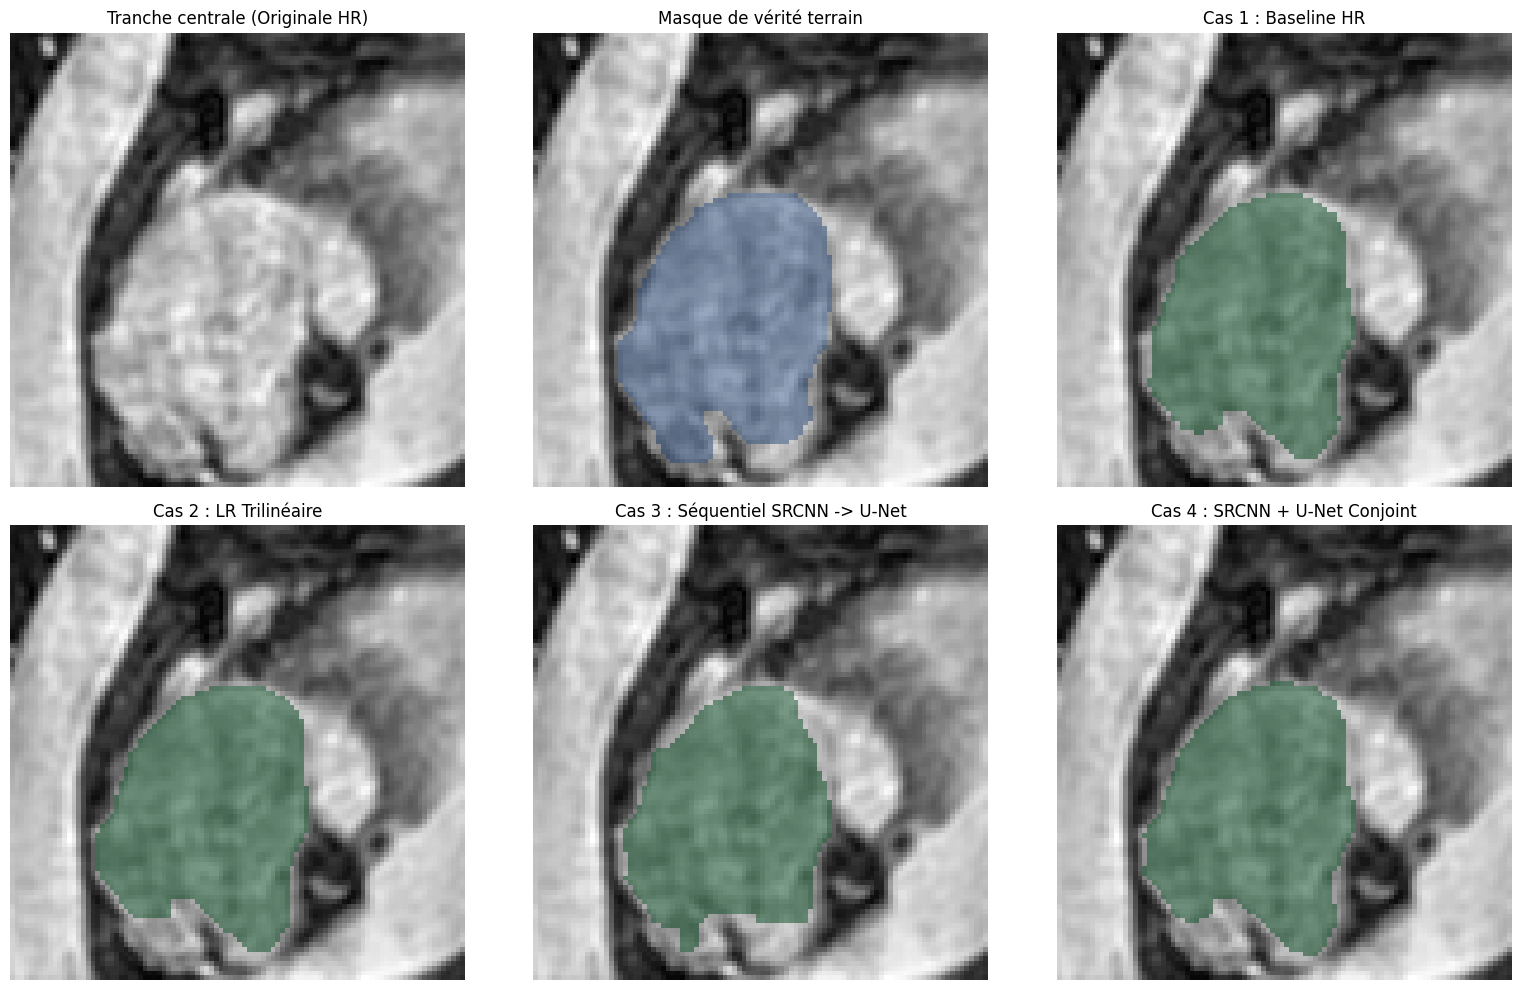

Visualisation enregistrée dans : /content/drive/MyDrive/TFE_Segmentation/3D


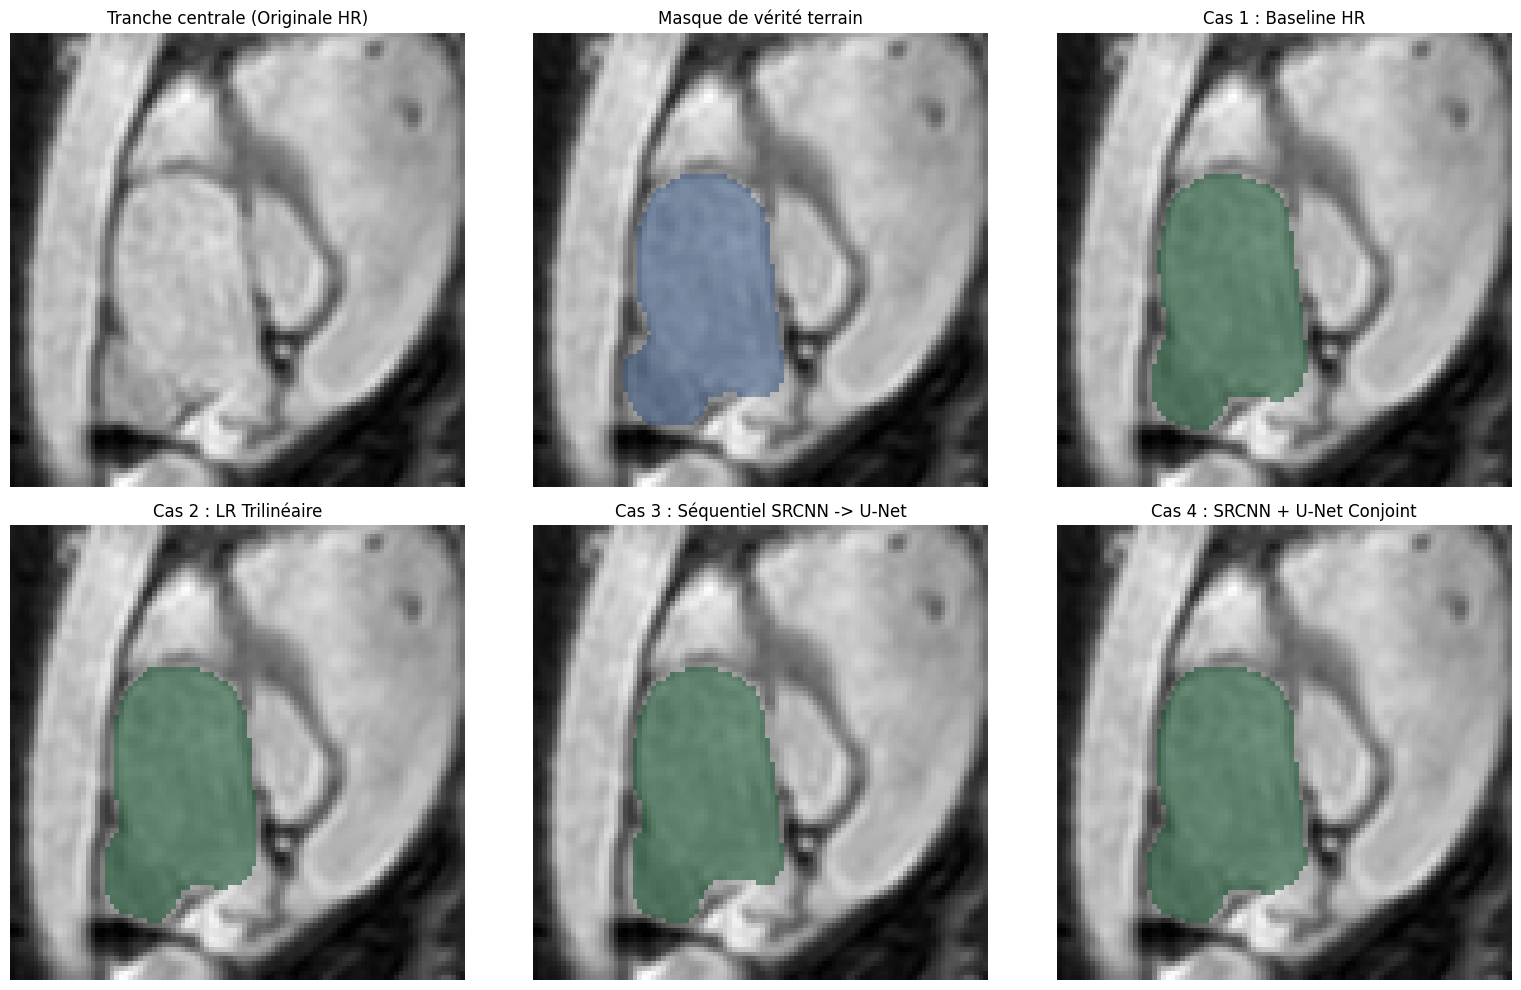

Visualisation enregistrée dans : /content/drive/MyDrive/TFE_Segmentation/3D


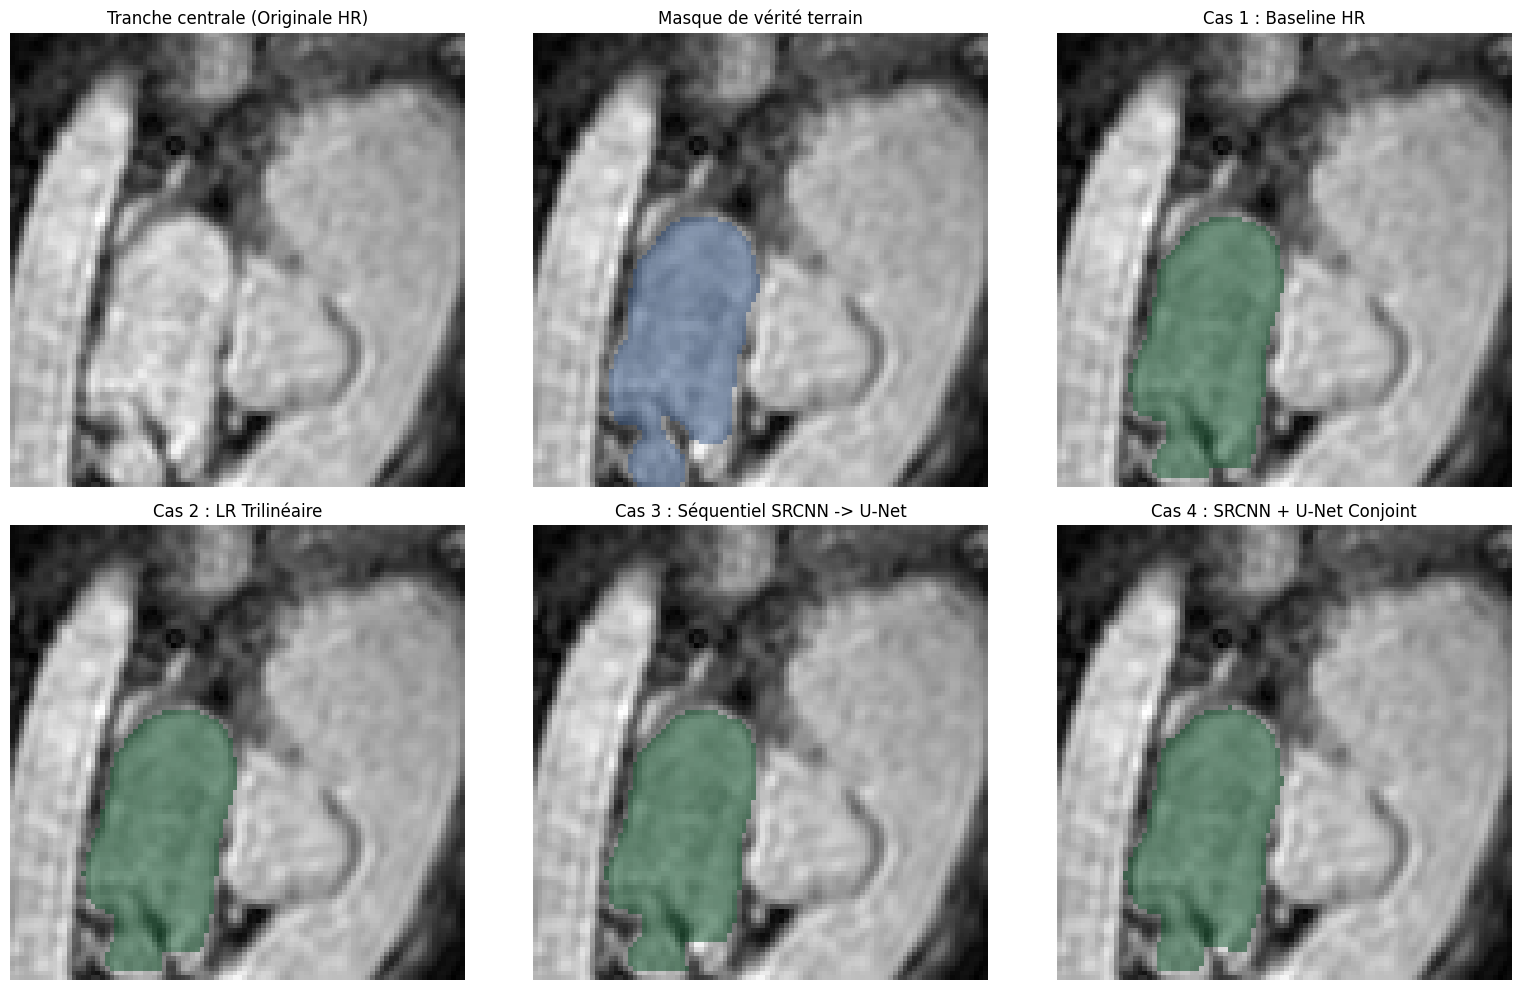

Visualisation enregistrée dans : /content/drive/MyDrive/TFE_Segmentation/3D


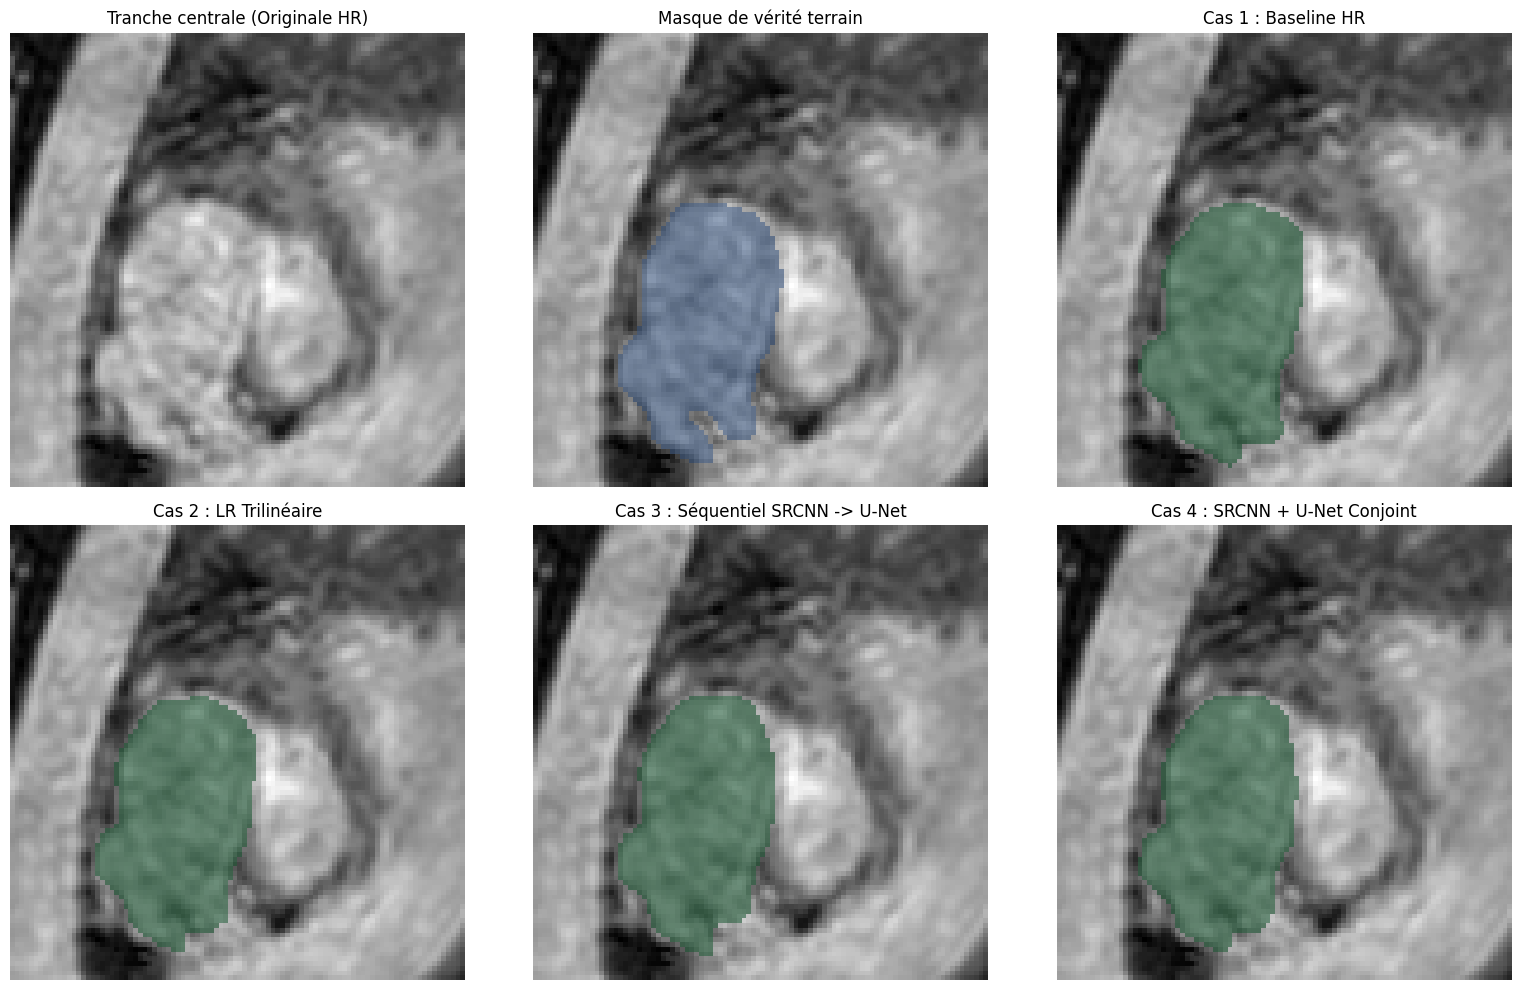

Visualisation enregistrée dans : /content/drive/MyDrive/TFE_Segmentation/3D


In [12]:
def afficher_comparaison_visuelle(idx_batch):
  # Recréation des modèles vides pour accueillir les poids
  unet_model1, unet_model2, unet_model3, unet_model4 = [creation_model() for _ in range(4)]
  srcnn_joint = SRCNN().to(device)
  srcnn_solo = SRCNN().to(device)

  # Chargement des meilleurs poids sauvegardés pour chaque modèle
  chemin_model = os.path.join(base_projet, '3D')

  # Dictionnaire de correspondance pour faciliter le chargement
  modeles_unet = {'deca_model1.pth' : unet_model1, 'deca_model2.pth' : unet_model2, 'deca_model3.pth' : unet_model3, 'deca_model4.pth' : unet_model4}

  # Boucle de chargement
  for nom_fichier, modele in modeles_unet.items():
    chemin_complet = os.path.join(chemin_model, nom_fichier)
    if os.path.exists(chemin_complet):
      modele.load_state_dict(torch.load(chemin_complet, map_location=device, weights_only=True))
    modele.eval()

  if os.path.exists(os.path.join(chemin_model, 'deca_srcnn.pth')):
    srcnn_joint.load_state_dict(torch.load(os.path.join(chemin_model, 'deca_srcnn.pth'), map_location=device, weights_only=True))
  if os.path.exists(os.path.join(chemin_model, 'deca_srcnn_isole.pth')):
    srcnn_solo.load_state_dict(torch.load(os.path.join(chemin_model, 'deca_srcnn_isole.pth'), map_location=device, weights_only=True))

  srcnn_joint.eval()
  srcnn_solo.eval()

  # Extraction sécurisée du batch sans crash d'itérateur et sans charger tout le DataLoader en RAM
  it = iter(val_loader)
  for _ in range(idx_batch):
    try:
      next(it)
    except StopIteration:
      it = iter(val_loader)
      break

  batch_hr, batch_lr, batch_labels = next(it)

  # Sélection intelligente du meilleur échantillon (avec le plus gros nombre de voxels cardiaques)
  somme_voxels = torch.sum(batch_labels, dim=(1, 2, 3, 4))
  idx_echantillon = torch.argmax(somme_voxels).item()

  if somme_voxels[idx_echantillon] == 0:
    print("Attention : Aucun masque expert trouvé dans ce batch.")

  # Extraction de l'image et du masque de vérité terrain (Ground Terrain) [1, C, H, W]
  img_hr = batch_hr[idx_echantillon:idx_echantillon+1].to(device)
  img_lr = batch_lr[idx_echantillon:idx_echantillon+1].to(device)
  label_gt = batch_labels[idx_echantillon:idx_echantillon+1].to(device)

  device_type = "cuda" if torch.cuda.is_available() else "cpu"
  seuil_confiance = 0.5
  # Définition d'un pinceau carré de 5x5 pixels pour forcer la fusion des îlots
  structure = np.ones((5, 5))

  predictions = []

  with torch.no_grad():
    with autocast(device_type=device_type, enabled=(device_type == 'cuda')):

      # Génération dynamique des entrées pour éviter le hardcoding
      taille_cible = img_hr.shape[2:]
      entrees_cas = [img_hr, F.interpolate(img_lr, size=taille_cible, mode='trilinear', align_corners=False), srcnn_solo(img_lr), srcnn_joint(img_lr)]

      modeles_cas = [unet_model1, unet_model2, unet_model3, unet_model4]

      # Recherche de la meilleure coupe
      # Addition des pixels du masque expert sur la largeur et la hauteur
      somme_pixels = torch.sum(label_gt[0, 0], dim=(0, 1))
      # Sélection de la profondeur Z où il y a le plus de pixels d'atrium
      indices_valides = torch.where(somme_pixels > 0)[0]
      if len(indices_valides) > 0:
        tranche_z = indices_valides[torch.argmax(somme_pixels[indices_valides])].item()
      else:
        tranche_z = label_gt.shape[4] // 2
      # Si expert 100% vide sur tout le volume, on prend le milieu par défaut

      # Boucle sur les 4 cas
      for entree, modele in zip(entrees_cas, modeles_cas):
        output = modele(entree)
        pred_prob = (torch.sigmoid(output) > seuil_confiance).float()
        # Filtre Monai sur le volume 3D complet
        pred = keep_largest(pred_prob)

        # Extraction de la coupe 2D centrale et application directe de la morphologie mathématique
        pred_np = pred[0, 0, :, :, tranche_z].cpu().numpy().T
        pred_morpho = ndimage.binary_fill_holes(ndimage.binary_closing(pred_np, structure=structure)).astype(float)
        predictions.append(pred_morpho)


  # Conversion des tenseurs en Numpy pour matplotlib
  img_display = img_hr[0, 0, :, :, tranche_z].cpu().numpy().T
  label_display = label_gt[0, 0, :, :, tranche_z].cpu().numpy().T

  # Affichage des images
  plt.figure(figsize=(16, 10))

  # Image d'origine (HR)
  plt.subplot(2, 3, 1)
  plt.imshow(img_display, cmap='gray')
  plt.title('Tranche centrale (Originale HR)')
  plt.axis('off')

  # Masque de vérité terrain (Ground Truth)
  plt.subplot(2, 3, 2)
  plt.imshow(img_display, cmap='gray')
  # Contour de l'expert en fond (rouge)
  if np.max(label_display) > 0:
    masque_bleu = np.ma.masked_where(label_display == 0, label_display)
    plt.imshow(masque_bleu, cmap='Blues', alpha=0.4, vmin=0, vmax=1)
    #plt.contour(label_display, colors='red', linewidths=2, levels=[0.5])
  plt.title('Masque de vérité terrain')
  plt.axis('off')

  # 4 cas d'études
  titres_cas = ['Cas 1 : Baseline HR', 'Cas 2 : LR Trilinéaire', 'Cas 3 : Séquentiel SRCNN -> U-Net', 'Cas 4 : SRCNN + U-Net Conjoint']
  positions_cas = [3, 4, 5, 6]

  for pos, pred, titre in zip(positions_cas, predictions, titres_cas):
    plt.subplot(2, 3, pos)
    plt.imshow(img_display, cmap='gray')
    # Contour du modèle par dessus (vert)
    if np.max(pred) > 0:
      # Masquage des pixels à O pour ne pas colorer le fond en noir, et affichage des pixels = 1 en vert
      masque_vert = np.ma.masked_where(pred == 0, pred)
      plt.imshow(masque_vert, cmap='Greens', alpha=0.5, vmin=0, vmax=1)
    plt.title(titre)
    plt.axis('off')

  plt.tight_layout()
  chemin_sauvegarde = os.path.join(chemin_model, f'deca_comparaison_visuelle_{idx_batch}.png')
  plt.savefig(chemin_sauvegarde, dpi=300, bbox_inches='tight')
  plt.show()
  print(f"Visualisation enregistrée dans : {chemin_model}")

for i in range(4):
  afficher_comparaison_visuelle(i)

# Diagnostic d'anomalies cardiaques et cartographie EDT

Patient 1
Topologie Modèle Brut (avant nettoyage) : 1 composantes connexes
Topologie Modèle Propre (après nettoyage) : 1 composantes connexes
Erreur relative de surface: -4.32%
Patient 2
Topologie Modèle Brut (avant nettoyage) : 1 composantes connexes
Topologie Modèle Propre (après nettoyage) : 1 composantes connexes
Erreur relative de surface: +2.61%
Patient 3
Topologie Modèle Brut (avant nettoyage) : 1 composantes connexes
Topologie Modèle Propre (après nettoyage) : 1 composantes connexes
Erreur relative de surface: +4.53%
Patient 4
Topologie Modèle Brut (avant nettoyage) : 1 composantes connexes
Topologie Modèle Propre (après nettoyage) : 1 composantes connexes
Erreur relative de surface: -2.18%


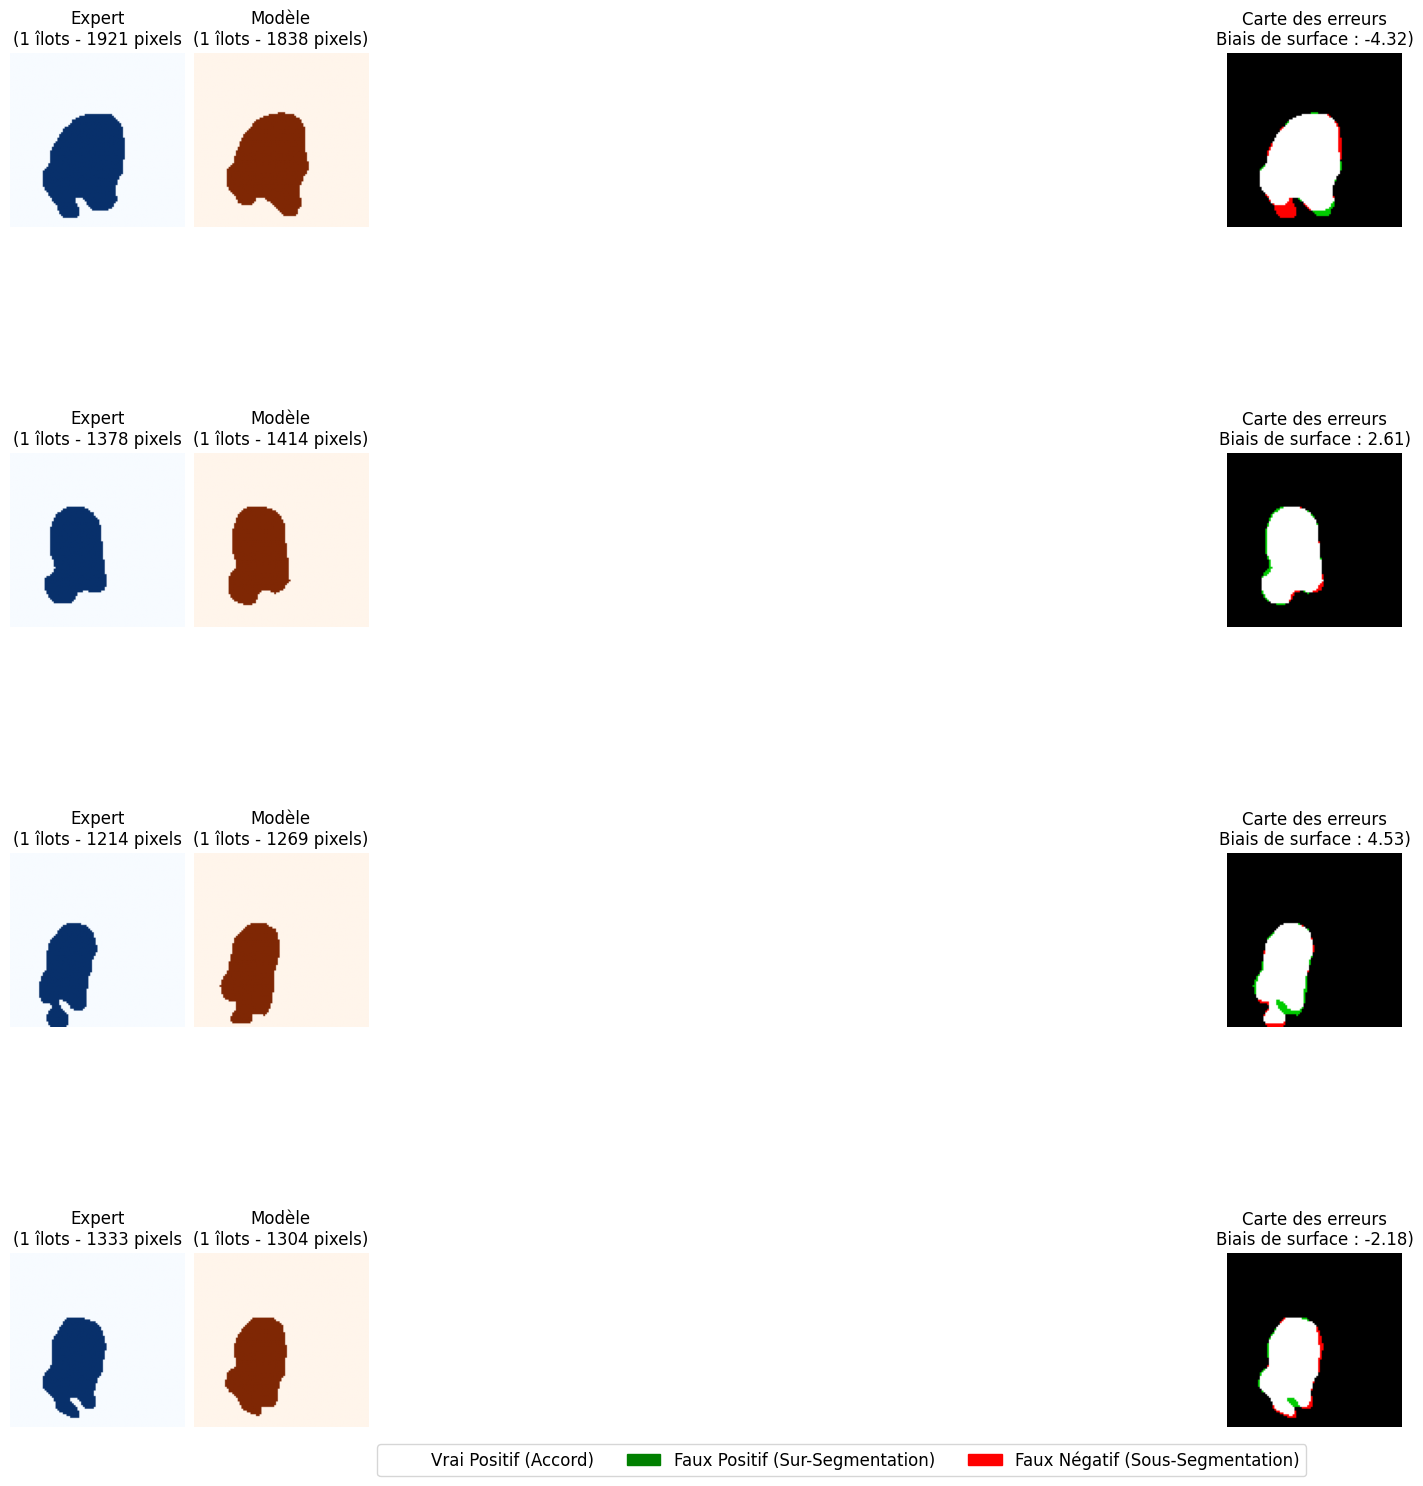

In [13]:
def analyser_topologie(masque_binaire):
  # Compte le nombre de composantes connexes (îlots) dans le masque
  masque_label = label(masque_binaire.astype(bool))
  nb_composantes = np.max(masque_label)
  return nb_composantes

def generer_carte_erreurs_cliniques(masque_expert, masque_predit):
  # Génération d'une carte RVB des erreurs :
  # Blanc : Vrai Positif (TP)
  # Vert : Faux Positif (FP) - Sur-segmentation (le modèle a débordé)
  # Rouge : Faux Négatif (FN) - Sous-segmentation (le modèle a raté une zone)
  expert_bool = masque_expert.astype(bool)
  pred_bool = masque_predit.astype(bool)

  # Calcul des masques logiques
  TP = expert_bool & pred_bool
  FP = pred_bool & ~expert_bool
  FN = expert_bool & ~pred_bool

  # Création de l'image RVB (H, W, 3)
  carte_rvb = np.zeros((masque_expert.shape[0], masque_expert.shape[1], 3), dtype=np.float32)

  # Remplissage des couleurs
  carte_rvb[TP] = [1.0, 1.0, 1.0] #Blanc
  carte_rvb[FP] = [0.0, 0.8, 0.0] #Vert
  carte_rvb[FN] = [1.0, 0.0, 0.0] #Rouge

  # Calcul des métriques de surface
  surface_expert = np.sum(expert_bool)
  surface_pred = np.sum(pred_bool)
  delta_surface = surface_pred - surface_expert

  # Erreur relative en pourcentage
  erreur_relative = (delta_surface / surface_expert) * 100 if surface_expert > 0 else 0.0

  return carte_rvb, surface_expert, surface_pred, erreur_relative

def executer_diagnostic_anomalies(nb_patients):
    """
    Exécute le pipeline complet de détection d'anomalies morphologiques et affiche
    un rapport clinique comparatif détaillé avec graphiques.
    """
    chemin_model = os.path.join(base_projet, '3D')

    # Chargement des modèles avec suffixe _nn
    unet_model3.load_state_dict(torch.load(os.path.join(chemin_model, 'deca_model3.pth'), map_location=device, weights_only=True))
    if os.path.exists(os.path.join(chemin_model, 'deca_srcnn.pth')):
      srcnn_joint.load_state_dict(torch.load(os.path.join(chemin_model, 'deca_srcnn.pth'), map_location=device, weights_only=True))

    unet_model4.eval()
    srcnn_joint.eval()

    device_type = "cuda" if torch.cuda.is_available() else "cpu"

    # Sélection intelligente des volumes centrales
    volumes_utiles = []
    for hr, lr, lbl in val_dataset_3d:
      # Filtre à 500 voxels car volume contient beaucoup plus de données
      if torch.sum(lbl) > 500:
        volumes_utiles.append((hr, lr, lbl))
      if len(volumes_utiles) == nb_patients:
        break

    if len(volumes_utiles) == 0:
      print("Erreur : Aucun volume avec un masque assez grand n'a été trouvée")
      return

    fig, axes = plt.subplots(nb_patients, 3, figsize=(14, 4*nb_patients), squeeze=False, constrained_layout=True)

    with torch.no_grad():
      # Boucle sur les tranches massives fraîchement sélectionnées
      for i, (hr, lr, lbl) in enumerate(volumes_utiles):

        # Reconstruction 5D voulue par PyTorch : [C, D, H, W] -> [B=1, C=1,D, H, W]
        img_lr = lr.unsqueeze(0).to(device)
        label_gt = lbl.unsqueeze(0).to(device)

        # Inférence Cas 4 Conjoint sécurisée sous AMP
        with torch.autocast(device_type=device_type, enabled=(device_type == 'cuda')):
          img_srcnn_joint = srcnn_joint(img_lr)
          output_model4 = unet_model4(img_srcnn_joint.float())

          # Nettoyage topologique de la prédiction
          pred_prob_brut = (torch.sigmoid(output_model4) > 0.5).float()
          pred_model_propre = keep_largest(pred_prob_brut)

        # Extraction de la tranche Z centrale pour le rapport 2D
        somme_pixels = torch.sum(label_gt[0, 0], dim=(0, 1))
        indices_valides = torch.where(somme_pixels > 0)[0]
        if len(indices_valides) > 0:
          tranche_z = indices_valides[torch.argmax(somme_pixels[indices_valides])].item()
        else:
          tranche_z = label_gt.shape[4] // 2

        # Preuve clinique : extraction des versions brutes et propres
        pred_brute_np = pred_prob_brut[0, 0, :, :, tranche_z].cpu().numpy().T
        pred_propre_np = pred_model_propre[0, 0, :, :, tranche_z].cpu().numpy().T

        # Fermeture morphologique pour lisser sur la tranche
        structure = np.ones((5, 5))
        pred_display = ndimage.binary_fill_holes(ndimage.binary_closing(pred_propre_np, structure=structure)).astype(float)

        # Reconversion en tableaux Numpy pour Scipy/Matplotlib
        label_display = label_gt[0, 0, :, :, tranche_z].cpu().numpy().T

        # Analyse topologique avant et après
        nb_ilots_bruts = analyser_topologie(pred_brute_np)
        nb_ilots_expert = analyser_topologie(label_display)
        nb_ilots_pred = analyser_topologie(pred_display)

        # Analyse des erreurs et des surfaces
        carte_rvb, surface_expert, surface_pred, erreur_relative = generer_carte_erreurs_cliniques(label_display, pred_display)

        # Affichage console
        print(f"Patient {i+1}")
        print(f"Topologie Modèle Brut (avant nettoyage) : {nb_ilots_bruts} composantes connexes")
        print(f"Topologie Modèle Propre (après nettoyage) : {nb_ilots_pred} composantes connexes")
        print(f"Erreur relative de surface: {erreur_relative:+.2f}%")

        # Colonne 1 : Vérité terrain
        axes[i, 0].imshow(label_display, cmap='Blues')
        axes[i, 0].set_title(f"Expert\n({nb_ilots_expert} îlots - {surface_expert} pixels")
        axes[i, 0].axis('off')

        # Colonne 2 : Prédiction modèle
        axes[i, 1].imshow(pred_display, cmap='Oranges')
        axes[i, 1].set_title(f"Modèle\n({nb_ilots_pred} îlots - {surface_pred} pixels)")
        axes[i, 1].axis('off')

        # Colonne 3 : Carte d'erreurs FP/FN
        axes[i, 2].imshow(carte_rvb)
        axes[i, 2].set_title(f"Carte des erreurs\nBiais de surface : {erreur_relative:.2f})")
        axes[i, 2].axis('off')

    # Légende personnalisée pour la carte RVB
    patch_tp = mpatches.Patch(color='white', label='Vrai Positif (Accord)')
    patch_fp = mpatches.Patch(color='green', label='Faux Positif (Sur-Segmentation)')
    patch_fn = mpatches.Patch(color='red', label='Faux Négatif (Sous-Segmentation)')
    plt.legend(handles=[patch_tp, patch_fp, patch_fn], loc='upper right', ncol=3, fontsize=12, bbox_to_anchor=(0.5, -0.05))

    # Sauvegarde
    plt.savefig(os.path.join(chemin_model, 'deca_diagnostic_anomalies.png'), dpi=300, facecolor='black', bbox_inches='tight')
    plt.show()

executer_diagnostic_anomalies(nb_patients=4)

# Rendu interactif 3D du meilleur cas

In [16]:
def afficher_rendu_3d_premium(volume_expert, volume_predit, titre):
    fig = go.Figure()

    # 1. Expert (Vérité Terrain) - Bleu translucide
    if np.max(volume_expert) > 0:
        verts_e, faces_e, _, _ = marching_cubes(volume_expert, level=0.5)
        fig.add_trace(go.Mesh3d(
            x=verts_e[:, 0], y=verts_e[:, 1], z=verts_e[:, 2],
            i=faces_e[:, 0], j=faces_e[:, 1], k=faces_e[:, 2],
            color='royalblue', opacity=0.35, name='Vérité Terrain (Expert)',
            lighting=dict(ambient=0.5, diffuse=0.8, specular=0.1, roughness=0.5),
            showscale=False
        ))

    # 2. Prédiction (Cas 3) - Or/Jaune éclatant
    if np.max(volume_predit) > 0:
        verts_p, faces_p, _, _ = marching_cubes(volume_predit, level=0.5)
        fig.add_trace(go.Mesh3d(
            x=verts_p[:, 0], y=verts_p[:, 1], z=verts_p[:, 2],
            i=faces_p[:, 0], j=faces_p[:, 1], k=faces_p[:, 2],
            color='gold', opacity=0.9, name='Modèle Séquentiel (Cas 3)',
            lighting=dict(ambient=0.6, diffuse=0.9, specular=0.5, roughness=0.1),
            showscale=False
        ))

    # 3. Mise en page "Dark Mode" pour publication
    fig.update_layout(
        title=dict(text=titre, font=dict(size=24, color='white'), x=0.5),
        scene=dict(
            xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False),
            bgcolor='rgb(15, 15, 20)' # Fond très sombre pour faire ressortir l'or et le bleu
        ),
        margin=dict(l=0, r=0, b=0, t=60),
        legend=dict(font=dict(color='white'), orientation="h", yanchor="bottom", y=0.02, xanchor="center", x=0.5)
    )
    fig.show()

# --- EXÉCUTION ---
print("Chargement du Champion (Cas 3) pour l'ultime rendu 3D...")
chemin_model = os.path.join(base_projet, '3D')

# Instanciation
unet_champion = creation_model()
srcnn_champion = SRCNN().to(device)

# Chargement des poids
unet_champion.load_state_dict(torch.load(os.path.join(chemin_model, 'deca_model3.pth'), map_location=device, weights_only=True))
srcnn_champion.load_state_dict(torch.load(os.path.join(chemin_model, 'deca_srcnn_isole.pth'), map_location=device, weights_only=True))
unet_champion.eval(); srcnn_champion.eval()

# On prend un excellent patient dans le batch de validation
it = iter(val_loader)
batch_hr, batch_lr, batch_labels = next(it)

img_lr = batch_lr[0:1].to(device)
label_gt = batch_labels[0:1].to(device)

device_type = "cuda" if torch.cuda.is_available() else "cpu"

with torch.no_grad():
    with autocast(device_type=device_type, enabled=(device_type == 'cuda')):
        # Inférence Séquentielle (SRCNN -> UNet)
        img_sr = srcnn_champion(img_lr)
        out = unet_champion(img_sr.float())

        # Binarisation ET Nettoyage Topologique
        pred_prob_brute = (torch.sigmoid(out) > 0.5).float()
        pred_propre = keep_largest(pred_prob_brute)

# Conversion Numpy pour Plotly
volume_expert_np = label_gt[0, 0].cpu().numpy()
volume_pred_np = pred_propre[0, 0].cpu().numpy()

# Affichage !
afficher_rendu_3d_premium(
    volume_expert_np,
    volume_pred_np,
    "<b>Segmentation 3D Optimale</b><br><i>Modèle Séquentiel (Cas 3) vs Vérité Terrain</i>"
)

Chargement du Champion (Cas 3) pour l'ultime rendu 3D...


TypeError: afficher_rendu_3d_premium() missing 1 required positional argument: 'titre'

# Diagnostic clinique 3D (fibrillation auriculaire)

Détection de fibrillation automatique - rapport clinique

Patient sélectionné (1/3)
Voxels cardiaques détectés : 62707
Volume calculé de l'atrium : 134.19 mL

Patient sélectionné (2/3)
Voxels cardiaques détectés : 51374
Volume calculé de l'atrium : 109.94 mL

Patient sélectionné (3/3)
Voxels cardiaques détectés : 45638
Volume calculé de l'atrium : 97.67 mL


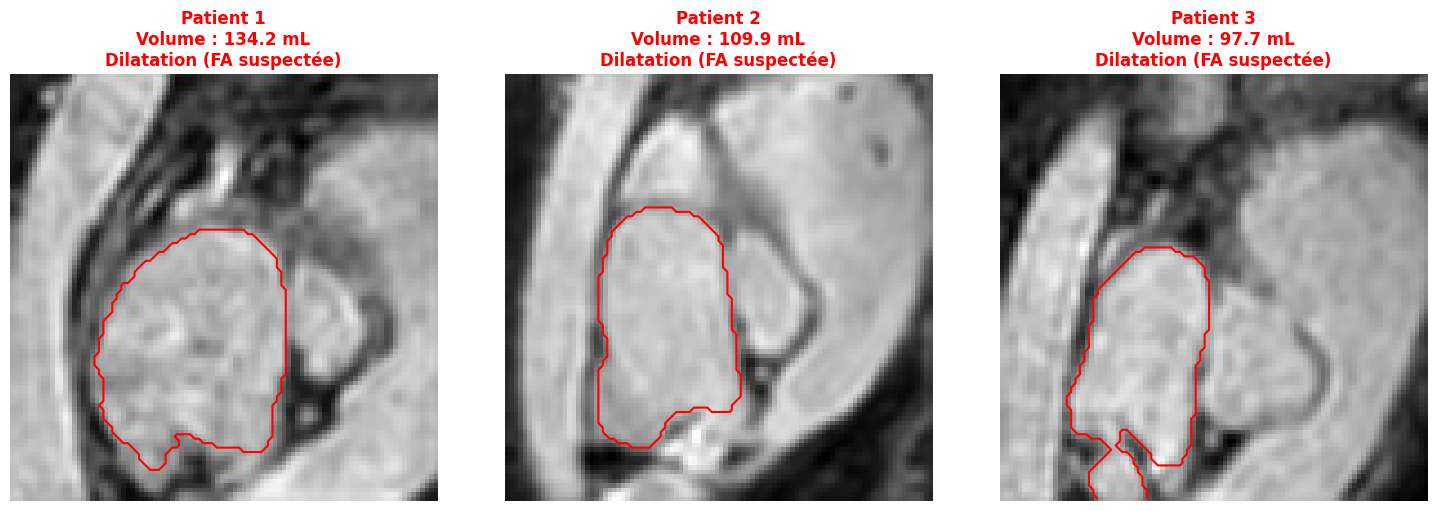

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def diagnostic_clinique(nb_patients_voulus=3):
    print("Détection de fibrillation automatique - rapport clinique")

    volume_voxel_ml = 0.00214 # Volume d'un voxel
    seuil_dilatation_ml = 70.0 # Seuil clinique critique de volume

    unet_champion = unet_model3
    srcnn_champion = srcnn_solo
    unet_champion.eval()
    srcnn_champion.eval()

    device_type = "cuda" if torch.cuda.is_available() else "cpu"

    # Préparation de la figure Matplotlib
    fig, axes = plt.subplots(1, nb_patients_voulus, figsize=(5 * nb_patients_voulus, 5))
    if nb_patients_voulus == 1:
        axes = [axes]

    patients_affiches = 0

    with torch.no_grad():
        for batch_hr, batch_lr, batch_labels in val_loader:
            img_lr = batch_lr[0:1].to(device)

            # Utilisation de la version globale correcte de l'autocast
            with torch.autocast(device_type=device_type, enabled=(device_type == 'cuda')):
                # Inférence Séquentielle
                img_sr = srcnn_champion(img_lr)
                output = unet_champion(img_sr)

                # Binarisation ET Nettoyage Topologique
                pred_prob = (torch.sigmoid(output) > 0.5).float()
                pred_propre = keep_largest(pred_prob)

            # Calcul du volume clinique
            pred_np = pred_propre[0, 0].cpu().numpy()
            nb_voxels = np.sum(pred_np == 1)
            volume_total_ml = nb_voxels * volume_voxel_ml

            est_dilate = volume_total_ml > seuil_dilatation_ml

            # --- AFFICHAGE ET GÉNÉRATION DE L'IMAGE ---
            print(f"\nPatient sélectionné ({patients_affiches + 1}/{nb_patients_voulus})")
            print(f"Voxels cardiaques détectés : {nb_voxels}")
            print(f"Volume calculé de l'atrium : {volume_total_ml:.2f} mL")

            # Recherche de la coupe Z optimale
            somme_pixels_z = np.sum(pred_np == 1, axis=(0, 1))
            tranche_z = np.argmax(somme_pixels_z)

            img_display = img_sr[0, 0, :, :, tranche_z].cpu().numpy().T
            pred_display = pred_np[:, :, tranche_z].T

            # --- DESSIN CLINIQUE ---
            # 1. Affichage de l'IRM en fond
            axes[patients_affiches].imshow(img_display, cmap='gray')

            # 2. Tracé du contour de la prédiction (ligne rouge fine)
            axes[patients_affiches].contour(pred_display, levels=[0.5], colors='red', linewidths=1.5)

            # Formatage du titre
            diagnostic_str = "Dilatation (FA suspectée)" if est_dilate else "Volume Normal"
            couleur_titre = 'red' if est_dilate else 'green'
            titre = f"Patient {patients_affiches + 1}\nVolume : {volume_total_ml:.1f} mL\n{diagnostic_str}"

            axes[patients_affiches].set_title(titre, color=couleur_titre, fontweight='bold')
            axes[patients_affiches].axis('off')

            patients_affiches += 1

            if patients_affiches >= nb_patients_voulus:
                break

    plt.tight_layout()
    plt.show()

diagnostic_clinique(nb_patients_voulus=3)